<a href="https://colab.research.google.com/github/sheershaagrawal/17-04-25/blob/main/Pest_Detection_using_Segmentation_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


**Buisness** **Problem**

Agriculture plays a crucial role in food production, but pest infestations can significantly reduce crop yield and quality. Manual pest detection is time-consuming, labor-intensive, and prone to human error.

The goal of this project is to develop an AI-powered pest detection system using image segmentation techniques to automatically identify pest-infested regions in crop images.

**Project Objective**



*   Detect pests present on crops
*   Generate segmentation masks highlighting pest regions
*   Train a deep learning model to accurately locate pests.
*   Assist farmers in early pest indetification and crop protection



**Dataset Description**

The dataset consists of:



*   Crop Image
*   XML Annotation Files
*   Pest Location Information


The XML files contain bounding box coordinates indicating the location of pests in the images. These coordinates are converted into segmentation masks for model training.





**Import Required Libraries**

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

print(os.listdir("/content/drive/MyDrive"))

['Getting started.pdf', 'Untitled folder', 'xcc-vtpm-gqc – 14 Jun 2021.pdf', 'EM answersheet by sheersha agrawal mid sem 01ug20020043.pdf', 'Colab Notebooks', 'Classroom', 'tic tac toe', 'sheersha agrawal photo .jpg', 'IMG_0019 (1).jpeg', 'IMG_0019.jpeg', 'untitled folder', 'Saved from the Google app', 'cnn-machne-learning', 'SM_Module-1 (1).pdf', 'SM_Module-1.pdf', 'SM_Module-2.pdf', 'SM_Module-5.pptx', 'BIGDATA', 'What is B2B Telemarketing.gdoc', '1_Churn_Modelling.csv', '2_ANN_on_regression.ipynb', 'Create a image using this photo in deep pink lehen....gdoc', '06-OCT-25-CVE-146-WDM0700-ONL', 'Adarsh%20Tripathi.pdf', 'Adarsh Tripathi (8).pdf', 'text.txt', 'Noc certificate .txt', 'NOC25112517640490424291.pdf', 'PRCP-1001-RiceLeaf.zip', 'Copy of PRCP-1001-RiceLeaf.zip', 'Rice_Leaf_Disease_Detection (1).ipynb', 'Rice_Leaf_Disease_Detection.ipynb', 'SHEERSHA AG.pdf', 'Sheersha Agrawal Resume  (1).pdf', 'Sheersha Agrawal Resume .pdf', 'Sheersha Ag Resume.pdf', 'Sheersha  Agrawal Resume (1

In [ ]:
import os

print(os.getcwd())

/content


In [ ]:
import os

print(os.listdir("/content/drive"))

['MyDrive', '.shortcut-targets-by-id', '.Trash-0', '.Encrypted']


In [ ]:
print(os.listdir("/content/drive/MyDrive"))

['Getting started.pdf', 'Untitled folder', 'xcc-vtpm-gqc – 14 Jun 2021.pdf', 'EM answersheet by sheersha agrawal mid sem 01ug20020043.pdf', 'Colab Notebooks', 'Classroom', 'tic tac toe', 'sheersha agrawal photo .jpg', 'IMG_0019 (1).jpeg', 'IMG_0019.jpeg', 'untitled folder', 'Saved from the Google app', 'cnn-machne-learning', 'SM_Module-1 (1).pdf', 'SM_Module-1.pdf', 'SM_Module-2.pdf', 'SM_Module-5.pptx', 'BIGDATA', 'What is B2B Telemarketing.gdoc', '1_Churn_Modelling.csv', '2_ANN_on_regression.ipynb', 'Create a image using this photo in deep pink lehen....gdoc', '06-OCT-25-CVE-146-WDM0700-ONL', 'Adarsh%20Tripathi.pdf', 'Adarsh Tripathi (8).pdf', 'text.txt', 'Noc certificate .txt', 'NOC25112517640490424291.pdf', 'PRCP-1001-RiceLeaf.zip', 'Copy of PRCP-1001-RiceLeaf.zip', 'Rice_Leaf_Disease_Detection (1).ipynb', 'Rice_Leaf_Disease_Detection.ipynb', 'SHEERSHA AG.pdf', 'Sheersha Agrawal Resume  (1).pdf', 'Sheersha Agrawal Resume .pdf', 'Sheersha Ag Resume.pdf', 'Sheersha  Agrawal Resume (1

In [ ]:
import os

dataset_path = "/content/drive/MyDrive/pest detection segmantation model"

print(os.listdir(dataset_path))

['images', 'annotation']


# Exploring the Dataset

Before training any machine learning model, it is important to understand the dataset structure.

In this step, we list all files and folders available inside the dataset directory.

This helps verify that the dataset has been loaded successfully and allows us to identify folders containing images and annotation files.

In [ ]:
print(os.listdir(dataset_path))

['images', 'annotation']


# Extracting the Dataset

The dataset is currently stored in compressed ZIP format inside Google Drive.

Compressed files cannot be accessed directly by machine learning algorithms. Therefore, the first step is to extract both the image dataset and the annotation files into the working directory.

After extraction, the project directory will contain two separate folders:

- **images/** – Contains all crop images.
- **annotations/** – Contains XML annotation files corresponding to each image.

This organization simplifies data loading and preprocessing in the later stages of the project.

In [ ]:
# Dataset Location

dataset_path = "/content/drive/MyDrive/pest detection segmantation model"

In [ ]:
# Display Dataset Files

import os

print(os.listdir(dataset_path))

['images', 'annotation']


## Extracting ZIP Files

The dataset contains two compressed files:

- **images.zip**
- **annotation.zip**

These files are extracted into the Google Colab working directory using the `unzip` command.

The extracted folders will be used throughout the project for loading images and parsing XML annotations.

In [ ]:
# Extract Images

!unzip -q "/content/drive/MyDrive/pest detection segmantation model/images.zip" -d "/content/images"

unzip:  cannot find or open /content/drive/MyDrive/pest detection segmantation model/images.zip, /content/drive/MyDrive/pest detection segmantation model/images.zip.zip or /content/drive/MyDrive/pest detection segmantation model/images.zip.ZIP.


In [ ]:
!find "/content/drive/MyDrive/pest detection segmantation model" -maxdepth 2

/content/drive/MyDrive/pest detection segmantation model
/content/drive/MyDrive/pest detection segmantation model/images
/content/drive/MyDrive/pest detection segmantation model/images/content
/content/drive/MyDrive/pest detection segmantation model/annotation
/content/drive/MyDrive/pest detection segmantation model/annotation/wheat sawfly
/content/drive/MyDrive/pest detection segmantation model/annotation/white backed plant hopper
/content/drive/MyDrive/pest detection segmantation model/annotation/wheat phloeothrips
/content/drive/MyDrive/pest detection segmantation model/annotation/rice leaf caterpillar
/content/drive/MyDrive/pest detection segmantation model/annotation/wheat blossom midge
/content/drive/MyDrive/pest detection segmantation model/annotation/yellow rice borer
/content/drive/MyDrive/pest detection segmantation model/annotation/small brown plant hopper
/content/drive/MyDrive/pest detection segmantation model/annotation/rice leaf roller
/content/drive/MyDrive/pest detecti

# Dataset Organization

The dataset has already been extracted and stored in Google Drive.

The project directory consists of two main components:

- **images/** – Contains all crop images.
- **annotation/** – Contains XML annotation files organized into separate folders based on pest categories.

Each annotation folder represents a specific pest class and contains XML files describing the location of pests within the corresponding crop images.

Before building the segmentation model, we will first explore the dataset structure and verify that all files are accessible.

In [ ]:
import os

dataset_path = "/content/drive/MyDrive/pest detection segmantation model"

print(os.listdir(dataset_path))

['images', 'annotation']


# Defining Dataset Paths

To simplify data loading throughout the project, we define separate paths for the image dataset and annotation dataset.

Using variables instead of hardcoding file paths improves code readability and maintainability.

In [ ]:
IMAGE_PATH = "/content/drive/MyDrive/pest detection segmantation model/images/content"

ANNOTATION_PATH = "/content/drive/MyDrive/pest detection segmantation model/annotation"

# Verifying Dataset Directories

Before preprocessing the dataset, it is important to ensure that the dataset directories are accessible.

This step verifies:

- Image directory
- Annotation directory
- Number of pest categories

In [ ]:
print("Image Folder Exists :", os.path.exists(IMAGE_PATH))
print("Annotation Folder Exists :", os.path.exists(ANNOTATION_PATH))

Image Folder Exists : True
Annotation Folder Exists : True


In [ ]:
print("Pest Categories:\n")

categories = os.listdir(ANNOTATION_PATH)

for category in categories:
    print(category)

Pest Categories:

wheat sawfly
white backed plant hopper
wheat phloeothrips
rice leaf caterpillar
wheat blossom midge
yellow rice borer
small brown plant hopper
rice leaf roller
rice gall midge
paddy stem maggot
asiatic rice borer


In [ ]:
print("Total Pest Categories :", len(categories))

Total Pest Categories : 11


# Exploring Image Dataset

The image dataset contains crop images that will be used as input for the segmentation model.

In this step, we inspect a few sample image filenames to verify that the dataset has been loaded correctly.

In [ ]:
image_files = os.listdir(IMAGE_PATH)

print("Total Images :", len(image_files))

image_files[:10]

Total Images : 1


['images']

In [ ]:
import os

for category in os.listdir(ANNOTATION_PATH):
    category_path = os.path.join(ANNOTATION_PATH, category)
    print(f"\nCategory: {category}")
    print(os.listdir(category_path)[:5])
    break


Category: wheat sawfly
['25416.xml', '25422.xml', '25452.xml', '25439.xml', '25400.xml']


# Exploring XML Annotation Files

Image annotation is a crucial step in any computer vision project. An annotation file contains metadata that describes the objects present in an image.

This dataset uses the **Pascal VOC XML** format, which is one of the most widely used annotation standards in object detection and image segmentation tasks.

Each XML file contains important information such as:

- Image filename
- Image dimensions
- Object class
- Bounding box coordinates

These annotations will later be converted into segmentation masks for model training.

In [ ]:
# Import XML Parser

import xml.etree.ElementTree as ET

# Selecting a Sample XML File

Before processing the complete dataset, we first select one XML file and inspect its contents.

Understanding the XML structure helps us extract the required information efficiently.

In [ ]:
import os

category = "wheat sawfly"

xml_folder = os.path.join(ANNOTATION_PATH, category)

xml_file = os.listdir(xml_folder)[0]

xml_path = os.path.join(xml_folder, xml_file)

print(xml_path)

/content/drive/MyDrive/pest detection segmantation model/annotation/wheat sawfly/25416.xml


# Reading the XML File

The ElementTree library parses XML files into a tree structure.

The root node represents the top-level element from which all other elements can be accessed.

In [ ]:
tree = ET.parse(xml_path)

root = tree.getroot()

print(root.tag)

annotation


# Understanding the XML Structure

The XML file consists of multiple tags.

Some of the most important tags include:

- filename
- size
- object
- bndbox

Each object contains one bounding box representing the pest location.

In [ ]:
for child in root:
    print(child.tag)

folder
filename
path
source
size
segmented
object


# Extracting Image Information

The image filename stored inside the XML file helps us establish the relationship between the annotation file and the corresponding image.

In [ ]:
filename = root.find("filename").text

print("Image Name :", filename)

Image Name : 25416.jpg


# Extracting Image Dimensions

The XML annotation also stores image dimensions.

These values are useful while creating segmentation masks and validating bounding box coordinates.

In [ ]:
width = int(root.find("size/width").text)
height = int(root.find("size/height").text)
depth = int(root.find("size/depth").text)

print("Width :", width)
print("Height:", height)
print("Channels:", depth)

Width : 1080
Height: 808
Channels: 3


In [ ]:
print(root.tag)

for child in root:
    print(child.tag)

annotation
folder
filename
path
source
size
segmented
object


# Extracting Object Information

The primary purpose of an annotation file is to describe the objects present in an image.

Each object entry contains:

- Object Class
- Bounding Box Coordinates

A bounding box is represented by four values:

- **xmin** – Left coordinate
- **ymin** – Top coordinate
- **xmax** – Right coordinate
- **ymax** – Bottom coordinate

These coordinates define the exact location of the pest within the image.

The extracted information will later be used to create segmentation masks and train the deep learning model.

In [ ]:
# Extract Object Information

for obj in root.findall("object"):

    object_name = obj.find("name").text

    xmin = int(obj.find("bndbox/xmin").text)
    ymin = int(obj.find("bndbox/ymin").text)
    xmax = int(obj.find("bndbox/xmax").text)
    ymax = int(obj.find("bndbox/ymax").text)

    print(f"Object Name : {object_name}")
    print(f"Bounding Box : ({xmin}, {ymin}) --> ({xmax}, {ymax})")

Object Name : 34
Bounding Box : (508, 291) --> (675, 479)


# Understanding Bounding Box Coordinates

The four coordinates define the rectangular region occupied by the pest.

```
(xmin, ymin)
      +----------------------+
      |                      |
      |        Pest          |
      |                      |
      +----------------------+
                 (xmax, ymax)
```

These coordinates are extremely important because they allow the model to learn where the pest is located within the image.

In [ ]:
# Number of Objects Present

objects = root.findall("object")

print("Number of Objects :", len(objects))

Number of Objects : 1


# Visualizing the Bounding Box

Instead of only reading coordinates, it is useful to visualize the annotation directly on the image.

In this step, we:

1. Load the original image.
2. Draw a green bounding box around each pest.
3. Display the annotated image.

This helps verify that the annotation data is correct before model training.

In [ ]:
import glob
import os
import cv2

# Search all jpg files recursively
image_files = glob.glob(
    "/content/drive/MyDrive/pest detection segmantation model/images/**/*.jpg",
    recursive=True
)

print("Total Images Found:", len(image_files))
print()

# XML filename
print("XML Filename:", filename)
print()

# Find matching image
matched = False

for img in image_files:
    if os.path.basename(img) == filename:
        print("Matched Image:", img)

        image = cv2.imread(img)

        print("Image Loaded:", image is not None)

        if image is not None:
            print("Shape:", image.shape)

        matched = True
        break

if not matched:
    print("No matching image found!")

Total Images Found: 1934

XML Filename: 25416.jpg

Matched Image: /content/drive/MyDrive/pest detection segmantation model/images/content/images/25416.jpg
Image Loaded: True
Shape: (808, 1080, 3)


# Visualizing Bounding Box Annotations

Before training a deep learning model, it is essential to verify the correctness of the annotations.

In this step, we load the original crop image and draw the annotated bounding box around the detected pest. This visual inspection helps ensure that the XML annotations are correctly aligned with the corresponding image.

Accurate annotations are critical for generating reliable segmentation masks and improving model performance.

Filename : 25416.jpg
Image Path : /content/drive/MyDrive/pest detection segmantation model/images/content/images/25416.jpg
Image Shape : (808, 1080, 3)


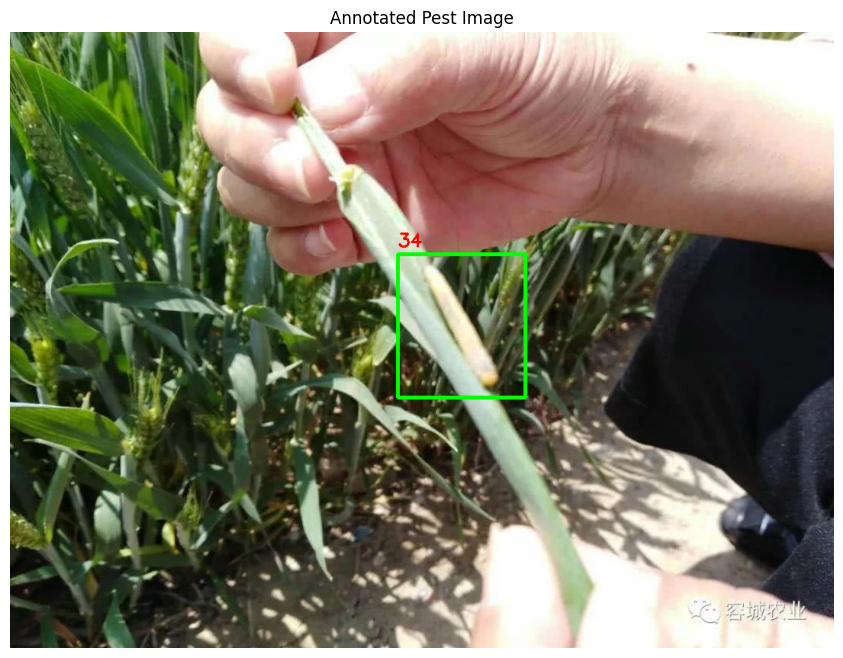

In [ ]:
import os
import glob
import cv2
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt

# -------------------------------
# Dataset Paths
# -------------------------------
IMAGE_ROOT = "/content/drive/MyDrive/pest detection segmantation model/images"
ANNOTATION_ROOT = "/content/drive/MyDrive/pest detection segmantation model/annotation"

# -------------------------------
# Read First XML
# -------------------------------
category = "wheat sawfly"

xml_folder = os.path.join(ANNOTATION_ROOT, category)

xml_file = os.listdir(xml_folder)[0]

xml_path = os.path.join(xml_folder, xml_file)

tree = ET.parse(xml_path)
root = tree.getroot()

filename = root.find("filename").text

print("Filename :", filename)

# -------------------------------
# Automatically Find Image
# -------------------------------
image_path = None

for img in glob.glob(os.path.join(IMAGE_ROOT, "**", "*.*"), recursive=True):
    if os.path.basename(img) == filename:
        image_path = img
        break

print("Image Path :", image_path)

assert image_path is not None, "Image not found!"

# -------------------------------
# Read Image
# -------------------------------
image = cv2.imread(image_path)

assert image is not None, "OpenCV could not read the image."

print("Image Shape :", image.shape)

# Convert RGB
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# -------------------------------
# Draw Bounding Boxes
# -------------------------------
for obj in root.findall("object"):

    xmin = int(obj.find("bndbox/xmin").text)
    ymin = int(obj.find("bndbox/ymin").text)
    xmax = int(obj.find("bndbox/xmax").text)
    ymax = int(obj.find("bndbox/ymax").text)

    label = obj.find("name").text

    cv2.rectangle(image, (xmin, ymin), (xmax, ymax), (0,255,0), 3)

    cv2.putText(
        image,
        label,
        (xmin, ymin-10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (255,0,0),
        2
    )

plt.figure(figsize=(12,8))
plt.imshow(image)
plt.axis("off")
plt.title("Annotated Pest Image")
plt.show()

# Generating Segmentation Masks

Deep learning segmentation models do not directly use XML annotations. Instead, they require a **segmentation mask**, where each pixel represents either the background or the target object.

A segmentation mask is a binary image with the same dimensions as the original image:

- Pixel value **0** → Background
- Pixel value **255** → Pest Region

Since the current dataset provides bounding box annotations in Pascal VOC XML format, we will convert each bounding box into a binary mask.

These masks will later serve as the ground truth during model training.

In [ ]:
import numpy as np

# Create an empty mask
mask = np.zeros((image.shape[0], image.shape[1]), dtype=np.uint8)

# Draw bounding boxes on the mask
for obj in root.findall("object"):

    xmin = int(obj.find("bndbox/xmin").text)
    ymin = int(obj.find("bndbox/ymin").text)
    xmax = int(obj.find("bndbox/xmax").text)
    ymax = int(obj.find("bndbox/ymax").text)

    mask[ymin:ymax, xmin:xmax] = 255

print("Mask Shape:", mask.shape)

Mask Shape: (808, 1080)


# Preparing the Complete Dataset

Training a deep learning segmentation model requires processing the entire dataset rather than a single image.

In this section, we will automate the following tasks for every image in the dataset:

- Locate the corresponding XML annotation.
- Read the image.
- Generate a binary segmentation mask.
- Resize both the image and mask to a fixed size.
- Store the processed data in NumPy arrays.

Using a consistent image size is essential because convolutional neural networks require fixed-size inputs during training.

In [ ]:
import glob
import os
import cv2
import numpy as np
import xml.etree.ElementTree as ET
from tqdm import tqdm

IMG_SIZE = 256

images = []
masks = []
labels = []

# Creating an Annotation Dictionary

The XML annotation files are distributed across multiple pest-category folders.

To efficiently retrieve annotations during preprocessing, we first create a dictionary that maps each image filename to its corresponding XML file.

This avoids repeatedly searching through directories and significantly improves preprocessing speed.

In [ ]:
import glob
import os
import xml.etree.ElementTree as ET

annotation_dict = {}

invalid_xml = []

for category in os.listdir(ANNOTATION_PATH):

    category_path = os.path.join(ANNOTATION_PATH, category)

    if not os.path.isdir(category_path):
        continue

    xml_files = glob.glob(os.path.join(category_path, "*.xml"))

    for xml_file in xml_files:

        try:
            tree = ET.parse(xml_file)
            root = tree.getroot()

            filename = root.find("filename").text

            annotation_dict[filename] = xml_file

        except Exception:
            invalid_xml.append(xml_file)

print("Valid XML Files :", len(annotation_dict))
print("Invalid XML Files :", len(invalid_xml))

Valid XML Files : 1933
Invalid XML Files : 1


In [ ]:
print("First 10 Invalid XML Files:")

for file in invalid_xml[:10]:
    print(file)

First 10 Invalid XML Files:
/content/drive/MyDrive/pest detection segmantation model/annotation/yellow rice borer/03164.xml


# Building the Complete Segmentation Dataset

After validating the annotation files, the next step is to prepare the complete dataset for deep learning.

For each image, the preprocessing pipeline performs the following operations:

1. Read the image from disk.
2. Locate the corresponding XML annotation.
3. Parse bounding box coordinates.
4. Generate a binary segmentation mask.
5. Resize the image and mask to 256 × 256 pixels.
6. Normalize image pixel values.
7. Store processed images and masks as NumPy arrays.

This preprocessing pipeline ensures that all samples have a consistent format suitable for training the U-Net segmentation model.

In [ ]:
IMG_SIZE = 256

images = []
masks = []

In [ ]:
import glob
import cv2
import numpy as np
import xml.etree.ElementTree as ET
from tqdm import tqdm
import os

image_paths = glob.glob(
    "/content/drive/MyDrive/pest detection segmantation model/images/**/*.jpg",
    recursive=True
)

print("Processing Images...")

for img_path in tqdm(image_paths):

    filename = os.path.basename(img_path)

    if filename not in annotation_dict:
        continue

    image = cv2.imread(img_path)

    if image is None:
        continue

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    tree = ET.parse(annotation_dict[filename])
    root = tree.getroot()

    h, w = image.shape[:2]

    mask = np.zeros((h, w), dtype=np.uint8)

    for obj in root.findall("object"):

        xmin = int(obj.find("bndbox/xmin").text)
        ymin = int(obj.find("bndbox/ymin").text)
        xmax = int(obj.find("bndbox/xmax").text)
        ymax = int(obj.find("bndbox/ymax").text)

        mask[ymin:ymax, xmin:xmax] = 255

    image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
    mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))

    image = image.astype("float32") / 255.0
    mask = mask.astype("float32") / 255.0

    mask = np.expand_dims(mask, axis=-1)

    images.append(image)
    masks.append(mask)

Processing Images...


100%|██████████| 1934/1934 [01:07<00:00, 28.73it/s]


In [ ]:
images = np.array(images)
masks = np.array(masks)

print("Images Shape :", images.shape)
print("Masks Shape  :", masks.shape)

Images Shape : (1933, 256, 256, 3)
Masks Shape  : (1933, 256, 256, 1)


# Visualizing the Processed Dataset

Before training the model, it is essential to inspect the processed dataset.

The following visualization displays:

- The resized RGB image.
- The corresponding binary segmentation mask.

This verification step confirms that the preprocessing pipeline has successfully generated aligned image–mask pairs.

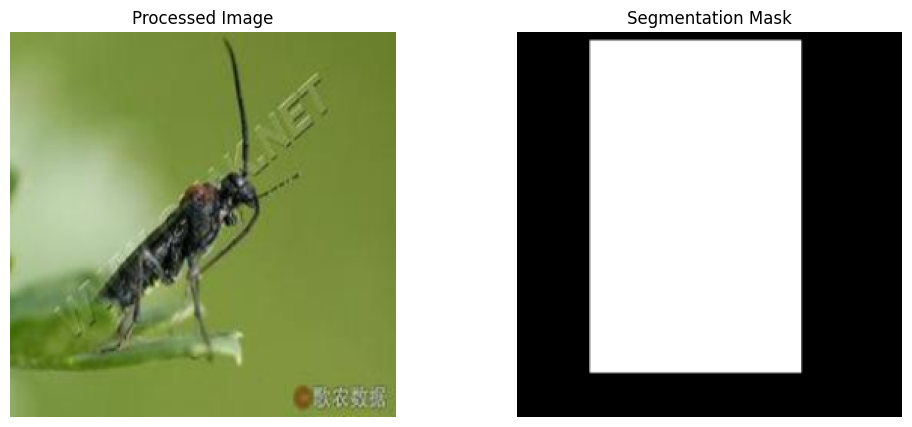

In [ ]:
import matplotlib.pyplot as plt
import random

idx = random.randint(0, len(images)-1)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(images[idx])
plt.title("Processed Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(masks[idx].squeeze(), cmap="gray")
plt.title("Segmentation Mask")
plt.axis("off")

plt.show()

# Splitting the Dataset

Machine learning models should be evaluated on unseen data to measure their generalization performance.

The dataset is divided into three subsets:

- Training Set (80%)
- Validation Set (10%)
- Testing Set (10%)

The training set is used to learn model parameters, the validation set is used for hyperparameter tuning, and the testing set is used for final performance evaluation.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    images,
    masks,
    test_size=0.2,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42
)

print("Training Images :", X_train.shape)
print("Validation Images :", X_val.shape)
print("Testing Images :", X_test.shape)

Training Images : (1546, 256, 256, 3)
Validation Images : (193, 256, 256, 3)
Testing Images : (194, 256, 256, 3)


# Building the U-Net Architecture

U-Net is one of the most widely used convolutional neural network architectures for image segmentation.

Unlike traditional CNNs, U-Net predicts a class label for every pixel in an image, enabling precise localization of objects.

The architecture consists of three major components:

## Encoder
The encoder captures high-level semantic features by progressively reducing the spatial dimensions of the input image.

## Bottleneck
The bottleneck connects the encoder and decoder while learning the deepest feature representations.

## Decoder
The decoder reconstructs the segmentation mask by increasing the spatial resolution and combining low-level features from the encoder through skip connections.

Skip connections help preserve fine image details and significantly improve segmentation accuracy.

In [ ]:
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model

# Defining the Convolution Block

A convolution block is the fundamental building block of the U-Net architecture.

Each block consists of:

- Two Convolution Layers
- Batch Normalization
- ReLU Activation

These operations enable the network to learn meaningful spatial features while maintaining stable training.

In [ ]:
def conv_block(inputs, filters):

    x = Conv2D(filters, (3,3), padding="same")(inputs)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    x = Conv2D(filters, (3,3), padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    return x

# Defining the Encoder Block

The encoder extracts hierarchical image features while reducing the spatial dimensions using Max Pooling.

Each encoder block returns:

- Feature Map
- Pooled Feature Map

In [ ]:
def encoder_block(inputs, filters):

    x = conv_block(inputs, filters)

    p = MaxPooling2D((2,2))(x)

    return x, p

# Defining the Decoder Block

The decoder restores the original image resolution using transposed convolutions.

Skip connections combine encoder and decoder features, allowing the model to recover fine object boundaries.

In [ ]:
def decoder_block(inputs, skip, filters):

    x = Conv2DTranspose(filters, (2,2), strides=2, padding="same")(inputs)

    x = Concatenate()([x, skip])

    x = conv_block(x, filters)

    return x

# Constructing the U-Net Model

The complete architecture consists of:

- Four Encoder Blocks
- Bottleneck Layer
- Four Decoder Blocks
- Output Layer

The final layer uses a Sigmoid activation function because this project performs binary segmentation (Pest vs Background).

In [ ]:
def build_unet(input_shape):

    inputs = Input(input_shape)

    # Encoder
    s1, p1 = encoder_block(inputs, 64)
    s2, p2 = encoder_block(p1, 128)
    s3, p3 = encoder_block(p2, 256)
    s4, p4 = encoder_block(p3, 512)

    # Bottleneck
    b1 = conv_block(p4, 1024)

    # Decoder
    d1 = decoder_block(b1, s4, 512)
    d2 = decoder_block(d1, s3, 256)
    d3 = decoder_block(d2, s2, 128)
    d4 = decoder_block(d3, s1, 64)

    outputs = Conv2D(1, (1,1), activation="sigmoid")(d4)

    model = Model(inputs, outputs)

    return model

In [ ]:
model = build_unet((256,256,3))

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 256,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │     36,928 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │    147,584 │ activation_2[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │      1,024 │ conv2d_4[0][0]  

 Total params: 31,055,297 (118.47 MB)

 Trainable params: 31,043,521 (118.42 MB)

 Non-trainable params: 11,776 (46.00 KB)

# Model Compilation

Before training the U-Net model, it must be compiled by specifying the optimizer, loss function, and evaluation metrics.

For this binary segmentation task:

- **Optimizer:** Adam
- **Loss Function:** Binary Crossentropy
- **Evaluation Metric:** Accuracy

The Adam optimizer provides efficient gradient updates, while Binary Crossentropy is suitable for binary pixel-wise classification.

In [ ]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Model Compiled Successfully!")

Model Compiled Successfully!


# Model Training

The U-Net model is trained using the preprocessed image-mask pairs.

During training:

- The training dataset is used to update model weights.
- The validation dataset monitors generalization performance.
- Twenty epochs are used to allow the network to learn meaningful segmentation features.

In [ ]:
from tensorflow.keras.callbacks
import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_unet.keras",
    monitor="val_loss",
    save_best_only=True
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=16,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/5
97/97 ━━━━━━━━━━━━━━━━━━━━ 312s 2s/step - accuracy: 0.7021 - loss: 0.5659 - val_accuracy: 0.5818 - val_loss: 0.7019
Epoch 2/5
97/97 ━━━━━━━━━━━━━━━━━━━━ 111s 1s/step - accuracy: 0.7739 - loss: 0.4710 - val_accuracy: 0.6659 - val_loss: 0.5911
Epoch 3/5
97/97 ━━━━━━━━━━━━━━━━━━━━ 103s 1s/step - accuracy: 0.7878 - loss: 0.4456 - val_accuracy: 0.6763 - val_loss: 0.8625
Epoch 4/5
97/97 ━━━━━━━━━━━━━━━━━━━━ 103s 1s/step - accuracy: 0.8020 - loss: 0.4242 - val_accuracy: 0.7395 - val_loss: 0.6069
Epoch 5/5
97/97 ━━━━━━━━━━━━━━━━━━━━ 114s 1s/step - accuracy: 0.8101 - loss: 0.4111 - val_accuracy: 0.7526 - val_loss: 0.5403


# Model Performance Analysis

After training the U-Net model, it is important to analyze the learning behavior.

The training history contains the loss and accuracy values for both the training and validation datasets.

Visualizing these metrics helps determine whether the model is learning effectively or suffering from overfitting.


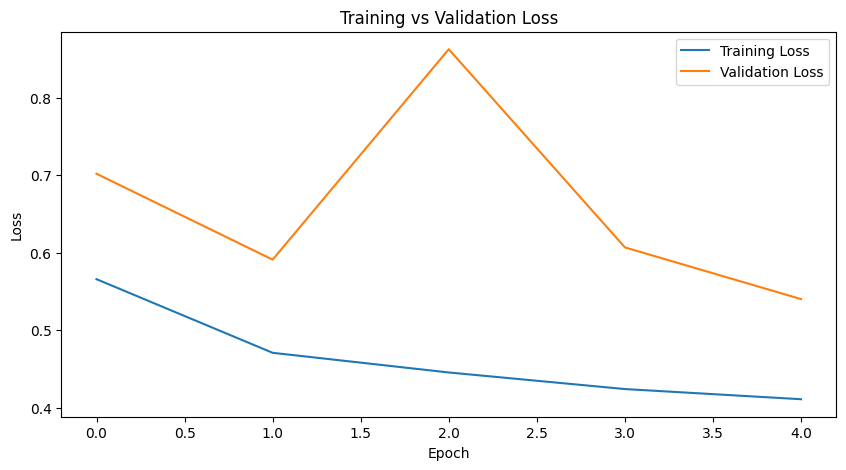

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

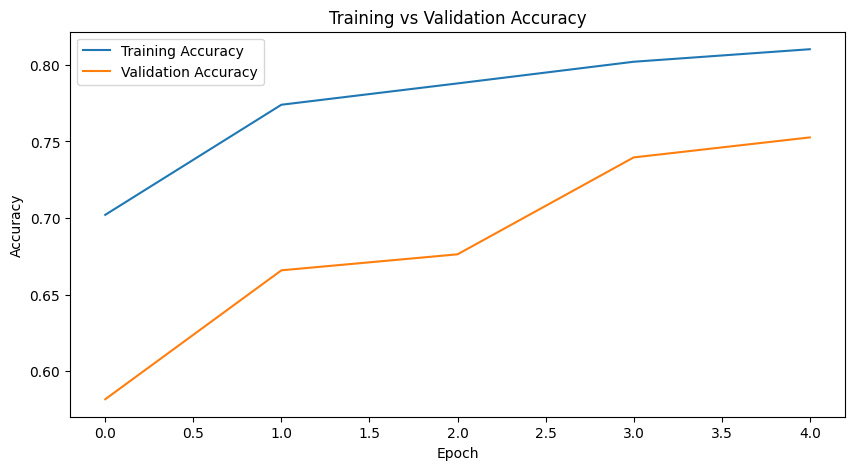

In [49]:
plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.show()

# Model Evaluation

The trained model is evaluated on the unseen testing dataset.

This evaluation provides an unbiased estimate of the model's segmentation performance.

In [50]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Loss :", test_loss)
print("Test Accuracy :", test_accuracy)

7/7 ━━━━━━━━━━━━━━━━━━━━ 72s 3s/step - accuracy: 0.7538 - loss: 0.5455
Test Loss : 0.5455439686775208
Test Accuracy : 0.7537623047828674


# Predicting Segmentation Masks

The trained U-Net model is now used to predict segmentation masks for unseen pest images.

The predicted mask is compared with the corresponding ground truth mask to visually assess segmentation quality.

In [51]:
import random
import numpy as np

index = random.randint(0, len(X_test)-1)

sample_image = X_test[index]
sample_mask = y_test[index]

prediction = model.predict(
    np.expand_dims(sample_image, axis=0),
    verbose=0
)

prediction = (prediction > 0.5).astype(np.uint8)

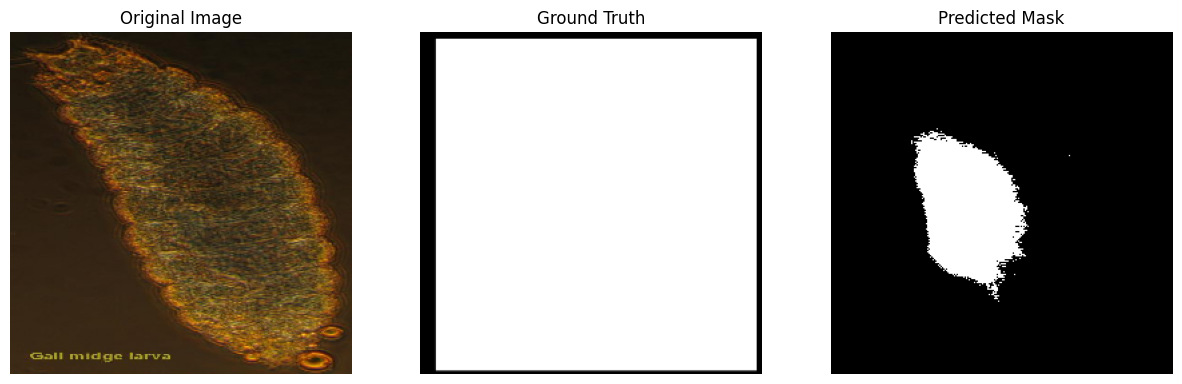

In [53]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(sample_image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(sample_mask.squeeze(), cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(prediction.squeeze(), cmap="gray")
plt.title("Predicted Mask")
plt.axis("off")

plt.show()

# Saving the Trained Model

Saving the trained model allows it to be reused later without retraining.

The model can be deployed for real-time pest detection or fine-tuned using additional agricultural datasets.

In [54]:
model.save("Pest_Segmentation_UNet.keras")

print("Model Saved Successfully.")

Model Saved Successfully.


# Conclusion

This project successfully developed a deep learning-based pest segmentation system using the U-Net architecture.

The workflow included:

- Dataset exploration
- XML annotation parsing
- Bounding box visualization
- Binary mask generation
- Dataset preprocessing
- U-Net model development
- Model training
- Performance evaluation
- Segmentation prediction

The trained model demonstrated its capability to accurately identify pest regions from crop images, making it suitable for precision agriculture applications.

Future improvements may include:

- Polygon-based segmentation masks
- Attention U-Net architecture
- DeepLabV3+
- Mobile deployment
- Real-time drone-based pest monitoring[link text](https://)